### 1. Import Library

In [1]:
import joblib
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity

### 2. Load Model dan Dataset

In [2]:
test_df         = pd.read_csv('../data/processed/test_clustered.csv')
cluster_profile = pd.read_csv('../data/processed/cluster_profile.csv', index_col=0)
cluster_centers = pd.read_csv('../data/processed/cluster_centers.csv')
ideal_profile   = pd.read_csv('../data/processed/ideal_profile.csv',
                               index_col=0, header=0).squeeze('columns')
kmeans          = joblib.load('../models/kmeans.pkl')
scaler          = joblib.load('../models/scaler.pkl')

with open('../models/cluster_names.json', 'r') as f:
    cluster_names = {int(k): v for k, v in json.load(f).items()}

print('Test set shape  :', test_df.shape)
print('Cluster names   :', cluster_names)
print('Ideal profile   :\n', ideal_profile.round(3))

Test set shape  : (7008, 11)
Cluster names   : {0: 'Low Load - Idle', 1: 'Medium Load - Night Shift', 2: 'High Load - Day Shift'}
Ideal profile   :
 Usage_kWh                                -0.056
Lagging_Current_Reactive.Power_kVarh     -0.953
Leading_Current_Reactive_Power_kVarh      2.607
CO2(tCO2)                                 0.000
Lagging_Current_Power_Factor              0.315
Leading_Current_Power_Factor           -436.337
NSM                                       0.435
hour                                      0.449
month                                     0.106
is_weekend                                0.559
Name: 1, dtype: float64


### 3. Feature Columns 

In [3]:
FEATURE_COLS = [
    'Usage_kWh',
    'Lagging_Current_Reactive.Power_kVarh',
    'Leading_Current_Reactive_Power_kVarh',
    'CO2(tCO2)',
    'Lagging_Current_Power_Factor',
    'Leading_Current_Power_Factor',
    'NSM',
    'hour',
    'month',
    'is_weekend'
]

### 4. Rules CBF

In [ ]:
# ─────────────────────────────────────────────
# Definisi rule rekomendasi berbasis fitur
#
# Setiap rule berisi:
#   - condition : fungsi yang menerima nilai fitur aktual
#                 dan nilai ideal, return True jika perlu rekomendasi
#   - message   : template rekomendasi (f-string)
#   - priority  : 1=urgent, 2=sedang, 3=info
#
# Perubahan threshold vs versi sebelumnya:
#   Lagging_Current_Power_Factor    : 0.1  → 0.3  (kurangi over-trigger)
#   Leading_Current_Power_Factor    : relatif ideal → absolut -50
#     Alasan: IQR fitur ini ~0.23 sehingga threshold relatif tidak stabil.
#     -50 ≈ raw PF < ~88% (di mana nilai normal mendekati 100%)
#   Lagging_Current_Reactive_Power  : 0.2  → 0.5  (kurangi over-trigger)
#   Leading_Current_Reactive_Power  : 0.2  → 0.5  (kurangi over-trigger)
# ─────────────────────────────────────────────

RULES = [
    {
        'feature'  : 'Lagging_Current_Power_Factor',
        'condition': lambda actual, ideal: actual < ideal - 0.3,
        'message'  : lambda actual, ideal: (
            f'Lagging PF = {actual:.3f}, di bawah profil efisien ({ideal:.3f}). '
            f'Gap = {ideal - actual:.3f} — pasang capacitor bank untuk koreksi daya reaktif lagging.'
        ),
        'priority' : 1
    },
    {
        'feature'  : 'Leading_Current_Power_Factor',
        # Threshold ABSOLUT (bukan relatif ideal) karena IQR fitur ini
        # sangat kecil setelah RobustScaler (~0.23). Nilai -50 ≈ raw PF < ~88%.
        'condition': lambda actual, ideal: actual < -50,
        'message'  : lambda actual, ideal: (
            f'Leading PF = {actual:.3f} (scaled) — terdeteksi rendah (raw PF jauh di bawah 100%). '
            f'Periksa kondisi kapasitor atau beban induktif pada sistem.'
        ),
        'priority' : 1
    },
    {
        'feature'  : 'Usage_kWh',
        'condition': lambda actual, ideal: actual > ideal + 0.3,
        'message'  : lambda actual, ideal: (
            f'Usage = {actual:.3f} (scaled), jauh di atas profil efisien ({ideal:.3f}). '
            f'Gap = {actual - ideal:.3f} — lakukan audit beban aktif dan identifikasi peralatan boros.'
        ),
        'priority' : 1
    },
    {
        'feature'  : 'CO2(tCO2)',
        'condition': lambda actual, ideal: actual > ideal + 0.3,
        'message'  : lambda actual, ideal: (
            f'CO2 = {actual:.3f} (scaled), di atas profil efisien ({ideal:.3f}). '
            f'Konsumsi karbon tinggi — evaluasi sumber energi atau efisiensi konversi daya.'
        ),
        'priority' : 2
    },
    {
        'feature'  : 'Lagging_Current_Reactive.Power_kVarh',
        'condition': lambda actual, ideal: actual > ideal + 0.5,
        'message'  : lambda actual, ideal: (
            f'Reactive power lagging = {actual:.3f}, lebih tinggi dari ideal ({ideal:.3f}). '
            f'Daya reaktif berlebih meningkatkan rugi-rugi jaringan — optimalkan kompensasi daya reaktif.'
        ),
        'priority' : 2
    },
    {
        'feature'  : 'Leading_Current_Reactive_Power_kVarh',
        'condition': lambda actual, ideal: actual < ideal - 0.5,
        'message'  : lambda actual, ideal: (
            f'Reactive power leading = {actual:.3f}, di bawah ideal ({ideal:.3f}). '
            f'Pertimbangkan penyesuaian beban kapasitif pada sistem distribusi.'
        ),
        'priority' : 3
    },
    {
        'feature'  : 'NSM',
        'condition': lambda actual, ideal: actual > ideal + 0.5,
        'message'  : lambda actual, ideal: (
            f'NSM = {actual:.3f} — operasional terjadi di jam peak (siang). '
            f'Pertimbangkan load shifting sebagian beban ke jam off-peak untuk mengurangi demand charge.'
        ),
        'priority' : 2
    },
    {
        'feature'  : 'is_weekend',
        'condition': lambda actual, ideal: actual < 0.5 and ideal >= 0.5,
        'message'  : lambda actual, ideal: (
            f'Record ini terjadi pada hari kerja dengan beban tinggi. '
            f'Jadwalkan maintenance berat di akhir pekan untuk mengurangi downtime produksi.'
        ),
        'priority' : 3
    }
]

print(f'Total rules terdefinisi: {len(RULES)}')


### 5. Fungsi CBF

In [5]:
def get_cbf_recommendation(record, cluster_centers, cluster_profile,
                            cluster_names, ideal_profile, rules):
    record_vec = record[FEATURE_COLS].values.reshape(1, -1)

    # Cosine similarity ke setiap cluster center
    sim_scores   = cosine_similarity(record_vec, cluster_centers.values)[0]
    best_cluster = int(np.argmax(sim_scores))

    # Gap aktual vs ideal
    feature_gaps = {
        feat: float(record[feat]) - float(ideal_profile[feat])
        for feat in FEATURE_COLS
    }

    # Evaluasi rules
    triggered_recs = []
    for rule in rules:
        feat   = rule['feature']
        actual = float(record[feat])
        ideal  = float(ideal_profile[feat])
        if rule['condition'](actual, ideal):
            triggered_recs.append({
                'feature' : feat,
                'message' : rule['message'](actual, ideal),
                'priority': rule['priority'],
                'gap'     : abs(actual - ideal)
            })

    triggered_recs.sort(key=lambda x: (x['priority'], -x['gap']))

    if not triggered_recs:
        triggered_recs = [{
            'feature' : '-',
            'message' : 'Profil konsumsi energi sudah mendekati kondisi ideal.',
            'priority': 3,
            'gap'     : 0.0
        }]

    return {
        'cluster'          : best_cluster,
        'cluster_name'     : cluster_names[best_cluster],
        'similarity_scores': sim_scores.round(4),
        'feature_gaps'     : feature_gaps,
        'recommendations'  : triggered_recs
    }

print('Fungsi CBF siap.')

Fungsi CBF siap.


### 6. Apply CBF ke Seluruh Test Set

In [6]:
X_test = test_df[FEATURE_COLS]

results = []
for idx, row in X_test.iterrows():
    res = get_cbf_recommendation(
        row, cluster_centers, cluster_profile,
        cluster_names, ideal_profile, RULES
    )
    results.append(res)

print(f'Total record diproses: {len(results)}')
print(f'Contoh output record pertama:')
print(f'  Cluster       : {results[0]["cluster"]} — {results[0]["cluster_name"]}')
print(f'  Similarity    : {results[0]["similarity_scores"]}')
print(f'  # Rekomendasi : {len(results[0]["recommendations"])}')

Total record diproses: 7008
Contoh output record pertama:
  Cluster       : 0 — Low Load - Idle
  Similarity    : [ 2.115e-01 -5.000e-04  1.000e-04]
  # Rekomendasi : 3


### 7. Bangun DataFrame Hasil

In [7]:
output_rows = []
for i, (idx, row) in enumerate(X_test.iterrows()):
    res = results[i]

    # Ambil rekomendasi prioritas 1 (paling kritis)
    top_rec = res['recommendations'][0]

    # Gap fitur paling besar
    top_gap_feat = max(res['feature_gaps'], key=lambda k: abs(res['feature_gaps'][k]))
    top_gap_val  = res['feature_gaps'][top_gap_feat]

    output_rows.append({
        'Cluster'             : res['cluster'],
        'Cluster_Name'        : res['cluster_name'],
        'Usage_kWh'           : row['Usage_kWh'],
        'CO2_tCO2'            : row['CO2(tCO2)'],
        'Lagging_PF'          : row['Lagging_Current_Power_Factor'],
        'Sim_Cluster0'        : res['similarity_scores'][0],
        'Sim_Cluster1'        : res['similarity_scores'][1],
        'Sim_Cluster2'        : res['similarity_scores'][2],
        'Top_Gap_Feature'     : top_gap_feat,
        'Top_Gap_Value'       : round(top_gap_val, 4),
        'Top_Priority'        : top_rec['priority'],
        'Top_Recommendation'  : top_rec['message'],
        'N_Recommendations'   : len(res['recommendations'])
    })

result_df = pd.DataFrame(output_rows)

print('=== SAMPLE RESULT ===\n')
print(result_df[['Cluster_Name', 'Usage_kWh', 'Lagging_PF',
                  'Top_Gap_Feature', 'Top_Priority', 'N_Recommendations']].head(10).to_string())

=== SAMPLE RESULT ===

      Cluster_Name  Usage_kWh  Lagging_PF               Top_Gap_Feature  Top_Priority  N_Recommendations
0  Low Load - Idle  -0.152454   -0.910232  Leading_Current_Power_Factor             1                  3
1  Low Load - Idle   0.967276   -0.173390  Leading_Current_Power_Factor             1                  5
2  Low Load - Idle   0.830930   -0.140262  Leading_Current_Power_Factor             1                  5
3  Low Load - Idle   0.517079   -0.324873  Leading_Current_Power_Factor             1                  5
4  Low Load - Idle   0.144241   -0.537002  Leading_Current_Power_Factor             1                  3
5  Low Load - Idle   0.071135   -0.668715  Leading_Current_Power_Factor             1                  3
6  Low Load - Idle   0.009712   -0.777451  Leading_Current_Power_Factor             1                  3
7  Low Load - Idle   0.004886   -0.835960  Leading_Current_Power_Factor             1                  3
8  Low Load - Idle   0.002101   

### 8. Cluster Profile (Test Set)

In [8]:
cluster_summary = result_df.groupby('Cluster_Name').agg(
    N_Records        = ('Cluster', 'count'),
    Avg_Usage        = ('Usage_kWh', 'mean'),
    Avg_CO2          = ('CO2_tCO2', 'mean'),
    Avg_Lagging_PF   = ('Lagging_PF', 'mean'),
    Avg_N_Recs       = ('N_Recommendations', 'mean'),
    Pct_Priority1    = ('Top_Priority', lambda x: (x == 1).mean() * 100)
).round(3)

print('\n=== CLUSTER PROFILE (TEST SET) ===\n')
print(cluster_summary.to_string())
print()
print('Keterangan kolom:')
print('  Avg_N_Recs    : rata-rata jumlah rekomendasi yang triggered per record')
print('  Pct_Priority1 : % record yang memiliki rekomendasi URGENT (priority 1)')


=== CLUSTER PROFILE (TEST SET) ===

                           N_Records  Avg_Usage  Avg_CO2  Avg_Lagging_PF  Avg_N_Recs  Pct_Priority1
Cluster_Name                                                                                       
High Load - Day Shift           1030      0.098    0.104           0.125       2.918         66.990
Low Load - Idle                 4746      0.440    0.740          -0.286       4.746        100.000
Medium Load - Night Shift       1232     -0.048    0.000           0.256       1.520         40.828

Keterangan kolom:
  Avg_N_Recs    : rata-rata jumlah rekomendasi yang triggered per record
  Pct_Priority1 : % record yang memiliki rekomendasi URGENT (priority 1)


### 9. Analisis Rule Frequency

In [9]:
# Hitung berapa kali setiap rule/fitur di-trigger di seluruh test set
rule_counts = {}
for res in results:
    for rec in res['recommendations']:
        feat = rec['feature']
        if feat != '-':
            rule_counts[feat] = rule_counts.get(feat, 0) + 1

rule_freq_df = pd.DataFrame(
    sorted(rule_counts.items(), key=lambda x: x[1], reverse=True),
    columns=['Feature', 'Triggered_Count']
)
rule_freq_df['Pct_of_TestSet'] = (rule_freq_df['Triggered_Count'] / len(results) * 100).round(1)

print('=== RULE FREQUENCY (seberapa sering tiap rule terpicu) ===\n')
print(rule_freq_df.to_string(index=False))
print()
print('→ Fitur dengan Triggered_Count tertinggi = masalah paling umum di industri ini.')

=== RULE FREQUENCY (seberapa sering tiap rule terpicu) ===

                             Feature  Triggered_Count  Pct_of_TestSet
Leading_Current_Reactive_Power_kVarh             5907            84.3
Lagging_Current_Reactive.Power_kVarh             5414            77.3
        Lagging_Current_Power_Factor             5001            71.4
                          is_weekend             4896            69.9
                           Usage_kWh             2614            37.3
                           CO2(tCO2)             2594            37.0
        Leading_Current_Power_Factor              428             6.1
                                 NSM              292             4.2

→ Fitur dengan Triggered_Count tertinggi = masalah paling umum di industri ini.


### 10. Visualisasi

C:\Users\Nicolaus Prima\AppData\Local\Temp\ipykernel_32212\4099633217.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=result_df, x='Cluster_Name', ax=axes[0], palette='Set2')
C:\Users\Nicolaus Prima\AppData\Local\Temp\ipykernel_32212\4099633217.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=result_df, x='Cluster_Name', y='Usage_kWh', ax=axes[1], palette='Set2')


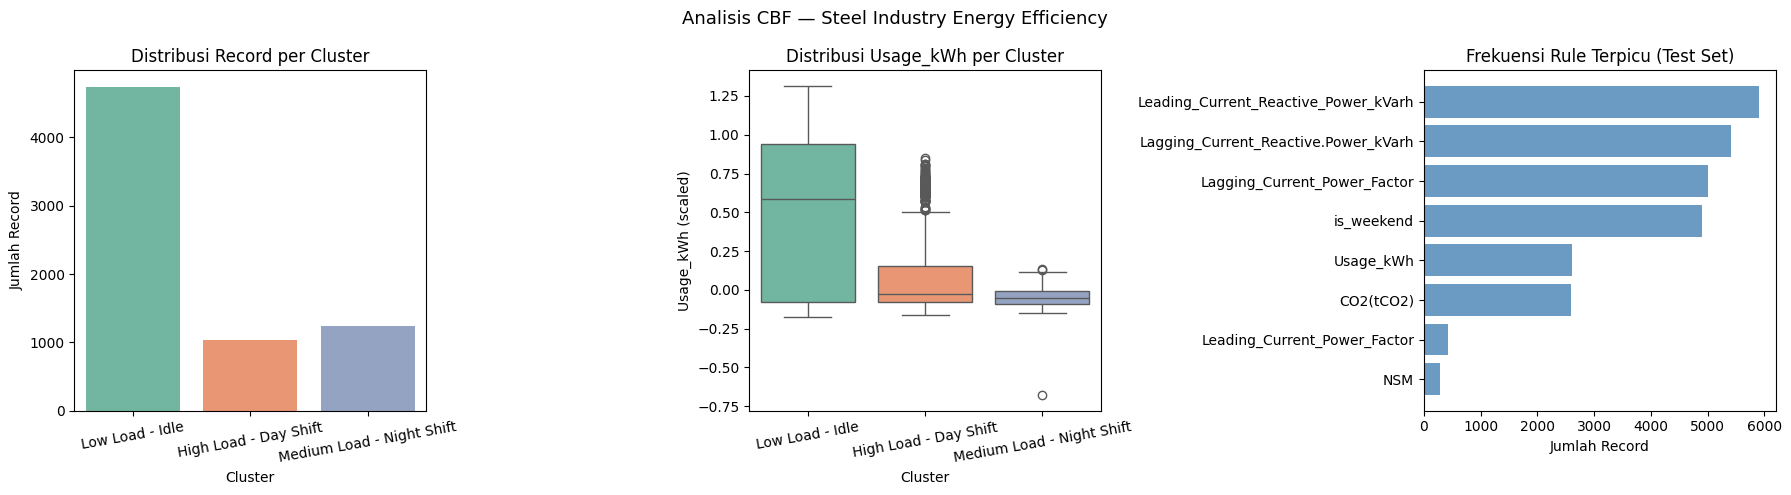

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Chart 1 — distribusi record per cluster
sns.countplot(data=result_df, x='Cluster_Name', ax=axes[0], palette='Set2')
axes[0].set_title('Distribusi Record per Cluster')
axes[0].set_xlabel('Cluster')
axes[0].set_ylabel('Jumlah Record')
axes[0].tick_params(axis='x', rotation=10)

# Chart 2 — distribusi Usage_kWh per cluster
sns.boxplot(data=result_df, x='Cluster_Name', y='Usage_kWh', ax=axes[1], palette='Set2')
axes[1].set_title('Distribusi Usage_kWh per Cluster')
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('Usage_kWh (scaled)')
axes[1].tick_params(axis='x', rotation=10)

# Chart 3 — frekuensi rule yang terpicu
if not rule_freq_df.empty:
    axes[2].barh(rule_freq_df['Feature'], rule_freq_df['Triggered_Count'],
                 color='steelblue', alpha=0.8)
    axes[2].set_title('Frekuensi Rule Terpicu (Test Set)')
    axes[2].set_xlabel('Jumlah Record')
    axes[2].invert_yaxis()

plt.suptitle('Analisis CBF — Steel Industry Energy Efficiency', fontsize=13)
plt.tight_layout()
plt.show()

### 11. Representative Sample per Cluster

In [11]:
# Record paling representatif = similarity tertinggi ke cluster-nya sendiri
result_df['Best_Sim'] = result_df.apply(
    lambda row: [row['Sim_Cluster0'], row['Sim_Cluster1'], row['Sim_Cluster2']][row['Cluster']],
    axis=1
)

representative = (
    result_df
    .sort_values('Best_Sim', ascending=False)
    .groupby('Cluster_Name')
    .head(3)
)

print('=== REPRESENTATIVE SAMPLE (top 3 per cluster) ===\n')
print(
    representative[[
        'Cluster_Name', 'Usage_kWh', 'Lagging_PF',
        'Best_Sim', 'N_Recommendations', 'Top_Recommendation'
    ]].to_string()
)

=== REPRESENTATIVE SAMPLE (top 3 per cluster) ===

                   Cluster_Name  Usage_kWh  Lagging_PF  Best_Sim  N_Recommendations                                                                                                                       Top_Recommendation
3504  Medium Load - Night Shift  -0.134265    0.321133    1.0000                  2                    Leading PF = -440.167, di bawah profil efisien (-436.337). Periksa kondisi kapasitor atau beban induktif pada sistem.
6118  Medium Load - Night Shift  -0.010679    0.321133    1.0000                  1                    Leading PF = -440.111, di bawah profil efisien (-436.337). Periksa kondisi kapasitor atau beban induktif pada sistem.
6124  Medium Load - Night Shift  -0.068899    0.321133    1.0000                  1                Reactive power leading = 2.390, di bawah ideal (2.607). Pertimbangkan penyesuaian beban kapasitif pada sistem distribusi.
6122      High Load - Day Shift  -0.072260    0.321133    1.0000 

### 12. Save Result

In [12]:
result_df.to_csv('../data/processed/energy_recommendations.csv', index=False)
rule_freq_df.to_csv('../data/processed/rule_frequency.csv', index=False)

print('File tersimpan:')
print('  ../data/processed/energy_recommendations.csv')
print('  ../data/processed/rule_frequency.csv')
print()
print(f'Total records  : {len(result_df)}')
print(f'Kolom output   : {list(result_df.columns)}')

File tersimpan:
  ../data/processed/energy_recommendations.csv
  ../data/processed/rule_frequency.csv

Total records  : 7008
Kolom output   : ['Cluster', 'Cluster_Name', 'Usage_kWh', 'CO2_tCO2', 'Lagging_PF', 'Sim_Cluster0', 'Sim_Cluster1', 'Sim_Cluster2', 'Top_Gap_Feature', 'Top_Gap_Value', 'Top_Priority', 'Top_Recommendation', 'N_Recommendations', 'Best_Sim']
